In [ ]:
# CLEAN START
!rm -rf /content/drive

from google.colab import drive
drive.mount('/content/drive')

rm: cannot remove '/content/drive/MyDrive': Operation canceled
rm: cannot remove '/content/drive/.shortcut-targets-by-id': Operation canceled
rm: cannot remove '/content/drive/Shareddrives': Operation canceled
rm: cannot remove '/content/drive/.Trash-0': Directory not empty
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Kelas: Tetragonula laeviceps
File: Tl (76).jpg
Path: /content/drive/MyDrive/Dataset_Split/train/Tetragonula laeviceps/Tl (76).jpg


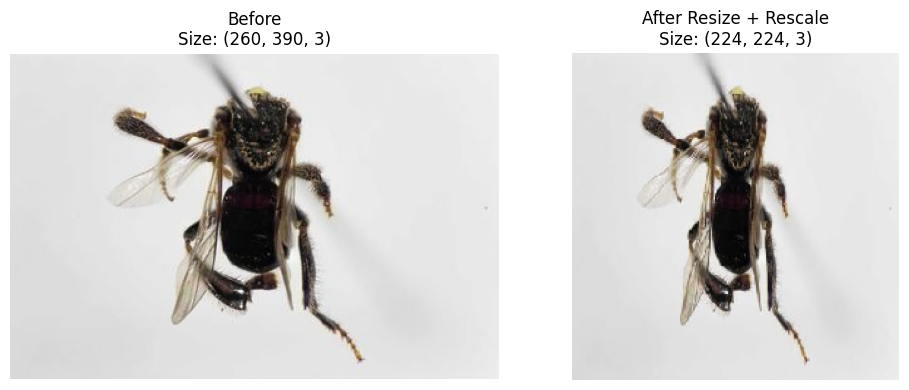

Pixel min/max BEFORE : 0.0 255.0
Pixel min/max AFTER  : 0.0 1.0


In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array


BASE = "/content/drive/MyDrive/Dataset_Split/train"

# pilih salah satu kelas (otomatis)
kelas = os.listdir(BASE)[1]
kelas_path = os.path.join(BASE, kelas)

# ambil satu gambar pertama
img_name = os.listdir(kelas_path)[99]
img_path = os.path.join(kelas_path, img_name)

print("Kelas:", kelas)
print("File:", img_name)
print("Path:", img_path)

# BEFORE
img_original = load_img(img_path)
img_original_arr = img_to_array(img_original)

# AFTER (RESIZE + RESCALE)
IMG_SIZE = (224, 224)
img_processed = load_img(img_path, target_size=IMG_SIZE)
img_processed_arr = img_to_array(img_processed) / 255.0  # rescale

# VISUALISASI
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img_original_arr.astype("uint8"))
plt.title(f"Before\nSize: {img_original_arr.shape}")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_processed_arr)
plt.title(f"After Resize + Rescale\nSize: {img_processed_arr.shape}")
plt.axis("off")

plt.tight_layout()
plt.show()


print("Pixel min/max BEFORE :", img_original_arr.min(), img_original_arr.max())
print("Pixel min/max AFTER  :", img_processed_arr.min(), img_processed_arr.max())

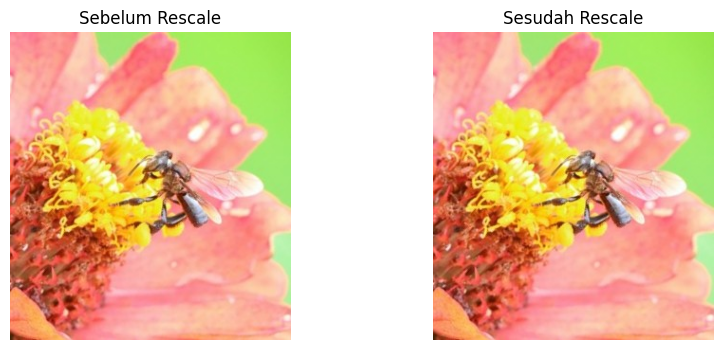

In [ ]:
import cv2
import matplotlib.pyplot as plt

# membaca gambar
image = cv2.imread("/content/drive/MyDrive/Dataset_Split/test/Geniotrigona thoracica/Gt j (3).jpeg")

# konversi BGR ke RGB
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# rescale (0-255 -> 0-1)
rescaled_image = image / 255.0

# menampilkan gambar
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Sebelum Rescale")
plt.imshow(image)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Sesudah Rescale")
plt.imshow(rescaled_image)
plt.axis("off")

plt.show()

skenario 1

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import os, json


# 1. PATH DATASET
BASE = "/content/drive/MyDrive/Dataset_Split"

TRAIN_DIR = os.path.join(BASE, "train")
VAL_DIR   = os.path.join(BASE, "val")

IMG_SIZE = (224,224)
BATCH = 32
EPOCH = 30

# 2. DATA GENERATOR
datagen = ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode="categorical",
    shuffle=True
)

val_gen = datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode="categorical",
    shuffle=False
)

NUM_CLASSES = train_gen.num_classes
print("Jumlah kelas:", NUM_CLASSES)

# 3. LOAD VGG16 BASELINE
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze semua layer (baseline)
for layer in base_model.layers:
    layer.trainable = False

# 4. CLASSIFIER (LOGITS)
inp = Input(shape=(224,224,3))

x = base_model(inp, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)

# TANPA SOFTMAX
out = Dense(NUM_CLASSES, activation=None)(x)

model_baseline = Model(inp, out)

# 5. COMPILE (WAJIB)
model_baseline.compile(
    optimizer=Adam(1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

model_baseline.summary()

# 6. TRAINING
history_baseline = model_baseline.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCH,
    verbose=1
)

# 7. SAVE MODEL
MODEL_PATH = "/content/drive/MyDrive/model_baseline_logits.h5"
model_baseline.save(MODEL_PATH)

print("Model logits berhasil disimpan")

# 8. SAVE HISTORY
HISTORY_PATH = "/content/drive/MyDrive/history_baseline_logits.json"

with open(HISTORY_PATH, "w") as f:
    json.dump(history_baseline.history, f, indent=4)

print("Skena 1 berhasil disimpan")

Found 560 images belonging to 4 classes.
Found 120 images belonging to 4 classes.
Jumlah kelas: 4


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,868 (56.38 MB)

 Trainable params: 66,180 (258.52 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 414s 23s/step - accuracy: 0.2661 - loss: 1.6451 - val_accuracy: 0.2417 - val_loss: 1.4195
Epoch 2/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 366ms/step - accuracy: 0.2446 - loss: 1.5701 - val_accuracy: 0.2833 - val_loss: 1.3561
Epoch 3/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 349ms/step - accuracy: 0.2768 - loss: 1.4752 - val_accuracy: 0.3667 - val_loss: 1.3273
Epoch 4/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 346ms/step - accuracy: 0.3018 - loss: 1.4151 - val_accuracy: 0.4750 - val_loss: 1.3061
Epoch 5/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 355ms/step - accuracy: 0.2964 - loss: 1.4011 - val_accuracy: 0.5167 - val_loss: 1.2879
Epoch 6/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 346ms/step - accuracy: 0.3393 - loss: 1.3758 - val_accuracy: 0.5417 - val_loss: 1.2720
Epoch 7/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 375ms/step - accuracy: 0.3911 - loss: 1.2991 - val_accuracy: 0.5500 - val_loss: 1.2555
Epoch 8/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 343ms/step - accuracy: 0.3714 - loss: 1.3053 - val_accuracy: 0.

Model logits berhasil disimpan
Skena 1 berhasil disimpan


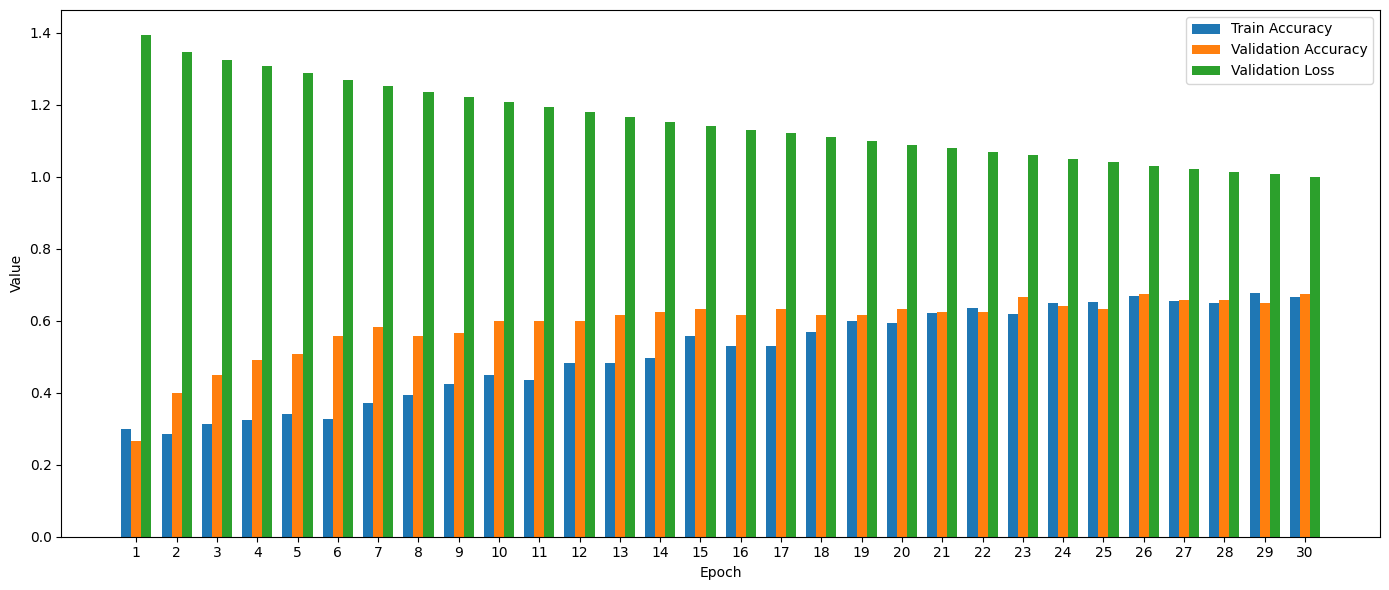

In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np

# LOAD HISTORY
with open("/content/drive/MyDrive/history_baseline_logits.json", "r") as f:
    history = json.load(f)

train_acc = history["accuracy"]
val_acc   = history["val_accuracy"]
val_loss  = history["val_loss"]

epochs = np.arange(1, len(train_acc) + 1)

width = 0.25  # lebar batang

plt.figure(figsize=(14,6))

plt.bar(epochs - width, train_acc, width=width, label="Train Accuracy")
plt.bar(epochs, val_acc, width=width, label="Validation Accuracy")
plt.bar(epochs + width, val_loss, width=width, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Value")
plt.legend()
plt.xticks(epochs)

plt.tight_layout()
plt.show()

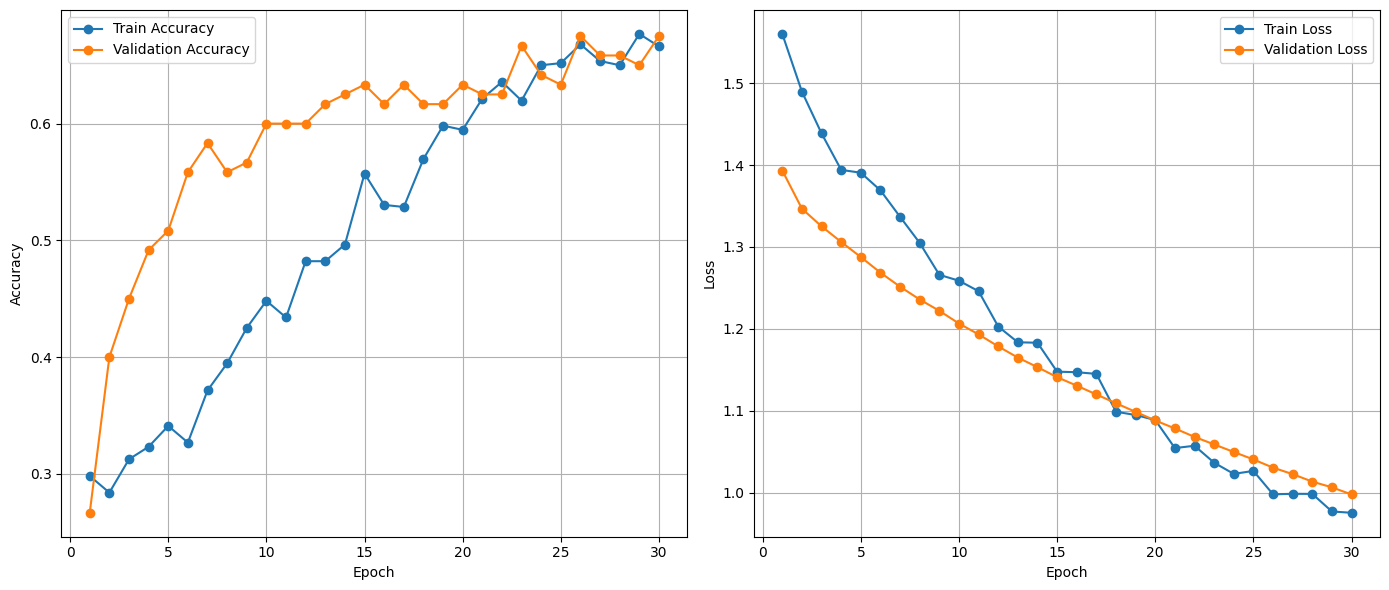

In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np

# 1. LOAD HISTORY
with open("/content/drive/MyDrive/history_baseline_logits.json", "r") as f:
    history = json.load(f)

# 2. AMBIL DATA
train_acc  = history["accuracy"]
val_acc    = history["val_accuracy"]
train_loss = history["loss"]
val_loss   = history["val_loss"]

# 3. EPOCH
epochs = np.arange(1, len(train_acc) + 1)

# 4. PLOT
plt.figure(figsize=(14,6))

# Accuracy
plt.subplot(1,2,1)
plt.plot(epochs, train_acc, marker='o', label="Train Accuracy")
plt.plot(epochs, val_acc, marker='o', label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1,2,2)
plt.plot(epochs, train_loss, marker='o', label="Train Loss")
plt.plot(epochs, val_loss, marker='o', label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Skena 2

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import os, json

# 1. LOAD DATA
BASE = "/content/drive/MyDrive/Dataset_Split"
TRAIN_DIR = os.path.join(BASE, "train")
VAL_DIR   = os.path.join(BASE, "val")

IMG_SIZE = (224, 224)
BATCH = 32
EPOCH = 30
LR = 1e-4

# 2. DATA GENERATOR
datagen = ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode="categorical",
    shuffle=True
)

val_gen = datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode="categorical",
    shuffle=False
)

NUM_CLASSES = train_gen.num_classes

# 3. BASE MODEL VGG16
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze semua layer
for layer in base_model.layers:
    layer.trainable = False

# 4. UNFREEZE BLOCK5
for layer in base_model.layers:
    if "block5" in layer.name:
        layer.trainable = True

print("\nLayer yang di-finetune:")
for layer in base_model.layers:
    if layer.trainable:
        print(layer.name)

# 5. CLASSIFIER (LOGITS VERSION)
inp = Input(shape=(224,224,3))

x = base_model(inp, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)

# TANPA SOFTMAX
logits = Dense(NUM_CLASSES)(x)
model_ft = Model(inp, logits)

# 6. COMPILE
model_ft.compile(
    optimizer=Adam(learning_rate=LR),

    # from_logits=True
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),

    metrics=["accuracy"]
)

model_ft.summary()

# 7. TRAINING
history_ft = model_ft.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCH,
    verbose=1
)

# 8. SAVE MODEL
model_ft.save("/content/drive/MyDrive/model_finetune_logits.h5")
print("Model logits berhasil disimpan!")

# 9. SAVE HISTORY
history_path = "/content/drive/MyDrive/history_finetune_logits.json"

with open(history_path, "w") as f:
    json.dump(history_ft.history, f, indent=4)

print("Skena 2 berhasil disimpan")

Found 560 images belonging to 4 classes.
Found 120 images belonging to 4 classes.

Layer yang di-finetune:
block5_conv1
block5_conv2
block5_conv3
block5_pool


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,868 (56.38 MB)

 Trainable params: 7,145,604 (27.26 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

Epoch 1/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 286s 16s/step - accuracy: 0.3784 - loss: 1.3779 - val_accuracy: 0.5917 - val_loss: 0.9559
Epoch 2/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 460ms/step - accuracy: 0.6578 - loss: 0.8373 - val_accuracy: 0.7083 - val_loss: 0.7682
Epoch 3/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 415ms/step - accuracy: 0.7478 - loss: 0.6735 - val_accuracy: 0.7167 - val_loss: 0.6592
Epoch 4/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 453ms/step - accuracy: 0.8312 - loss: 0.4915 - val_accuracy: 0.7750 - val_loss: 0.5878
Epoch 5/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 414ms/step - accuracy: 0.8634 - loss: 0.4002 - val_accuracy: 0.7500 - val_loss: 0.6679
Epoch 6/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 444ms/step - accuracy: 0.8768 - loss: 0.3425 - val_accuracy: 0.7667 - val_loss: 0.6931
Epoch 7/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 541ms/step - accuracy: 0.8904 - loss: 0.2916 - val_accuracy: 0.7750 - val_loss: 0.7246
Epoch 8/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 454ms/step - accuracy: 0.8999 - loss: 0.3025 - val_accuracy: 0

Model logits berhasil disimpan!
Skena 2 berhasil disimpan


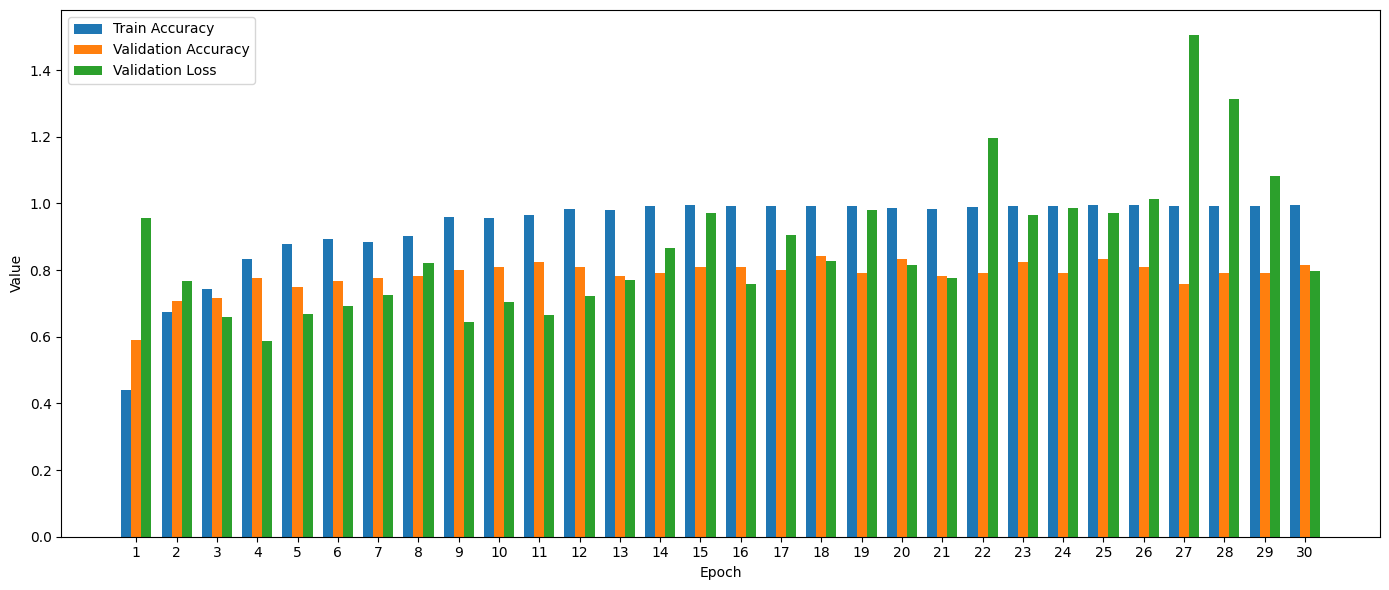

In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np

# LOAD HISTORY
with open("/content/drive/MyDrive/history_finetune_logits.json", "r") as f:
    history = json.load(f)

train_acc = history["accuracy"]
val_acc   = history["val_accuracy"]
val_loss  = history["val_loss"]

epochs = np.arange(1, len(train_acc) + 1)

width = 0.25  # lebar batang

plt.figure(figsize=(14,6))

plt.bar(epochs - width, train_acc, width=width, label="Train Accuracy")
plt.bar(epochs, val_acc, width=width, label="Validation Accuracy")
plt.bar(epochs + width, val_loss, width=width, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Value")
plt.legend()
plt.xticks(epochs)

plt.tight_layout()
plt.show()

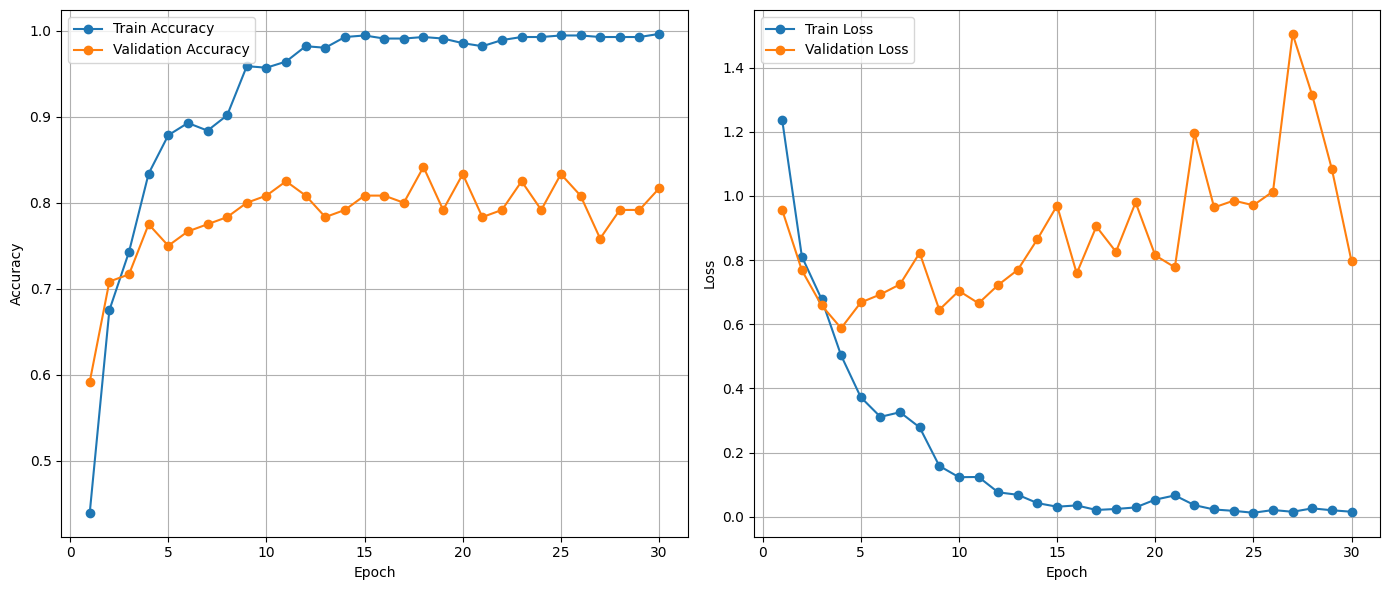

In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np

# 1. LOAD HISTORY
with open("/content/drive/MyDrive/history_finetune_logits.json", "r") as f:
    history = json.load(f)

# 2. AMBIL DATA
train_acc  = history["accuracy"]
val_acc    = history["val_accuracy"]
train_loss = history["loss"]
val_loss   = history["val_loss"]

# 3. EPOCH
epochs = np.arange(1, len(train_acc) + 1)

# 4. PLOT
plt.figure(figsize=(14,6))

# Accuracy
plt.subplot(1,2,1)
plt.plot(epochs, train_acc, marker='o', label="Train Accuracy")
plt.plot(epochs, val_acc, marker='o', label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1,2,2)
plt.plot(epochs, train_loss, marker='o', label="Train Loss")
plt.plot(epochs, val_loss, marker='o', label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Proses augmentasi

In [ ]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from PIL import Image, ImageEnhance


BASE_TRAIN = "/content/drive/MyDrive/Dataset_Split/train"
OUTPUT_AUG = "/content/drive/MyDrive/Dataset_Train_Augmented"
IMG_SIZE = (224,224)

os.makedirs(OUTPUT_AUG, exist_ok=True)

for cls in os.listdir(BASE_TRAIN):

    cls_path = os.path.join(BASE_TRAIN, cls)
    if not os.path.isdir(cls_path):
        continue

    out_cls = os.path.join(OUTPUT_AUG, cls)
    os.makedirs(out_cls, exist_ok=True)

    images = os.listdir(cls_path)

    print(f"Memproses kelas: {cls}")
    print(f"Jumlah gambar asli: {len(images)}")

    for img_name in images:
        img_path = os.path.join(cls_path, img_name)

        # Load & resize
        img = load_img(img_path, target_size=IMG_SIZE)
        x = img_to_array(img).astype("uint8")
        img_pil = Image.fromarray(x)

        # Simpan gambar asli
        img_pil.save(os.path.join(out_cls, img_name))

        w, h = img_pil.size

        # 1. ROTATION (20 derajat)
        rotated = img_pil.rotate(20)
        rotated.save(os.path.join(out_cls, f"rot_{img_name}"))

        # 2. SHEAR (horizontal shear)
        shear_factor = 0.2
        shear_matrix = (1, shear_factor, 0,
                         0, 1, 0)
        sheared = img_pil.transform(
            img_pil.size,
            Image.AFFINE,
            shear_matrix,
            resample=Image.BICUBIC
        )
        sheared.save(os.path.join(out_cls, f"shear_{img_name}"))

        # 3. ZOOM
        zoom_factor = 0.2
        crop_w = int(w * (1 - zoom_factor))
        crop_h = int(h * (1 - zoom_factor))
        left = (w - crop_w) // 2
        top = (h - crop_h) // 2
        right = left + crop_w
        bottom = top + crop_h

        zoomed = img_pil.crop((left, top, right, bottom)).resize(IMG_SIZE)
        zoomed.save(os.path.join(out_cls, f"zoom_{img_name}"))

        # 4. BRIGHTNESS
        enhancer = ImageEnhance.Brightness(img_pil)
        bright = enhancer.enhance(1.3)  # >1 lebih terang
        dark = enhancer.enhance(0.7)    # <1 lebih gelap
        bright.save(os.path.join(out_cls, f"bright_{img_name}"))
        dark.save(os.path.join(out_cls, f"dark_{img_name}"))

        # 5. HORIZONTAL FLIP
        flipped = img_pil.transpose(Image.FLIP_LEFT_RIGHT)
        flipped.save(os.path.join(out_cls, f"flip_{img_name}"))

print("Augmentasi selesai untuk semua kelas")

Memproses kelas: Geniotrigona thoracica
Jumlah gambar asli: 140
Memproses kelas: Tetragonula laeviceps
Jumlah gambar asli: 140
Memproses kelas: Tetragonula testaceitarsis
Jumlah gambar asli: 140
Memproses kelas: Tetrigona binghami
Jumlah gambar asli: 140
Augmentasi selesai untuk semua kelas


In [ ]:
import os

DATASET_DIR = "/content/drive/MyDrive/Dataset_Train_Augmented"

total = 0

for cls in os.listdir(DATASET_DIR):
    class_path = os.path.join(DATASET_DIR, cls)

    if os.path.isdir(class_path):
        count = len([
            f for f in os.listdir(class_path)
            if f.lower().endswith(('.jpg','.jpeg','.png'))
        ])

        print(f"{cls}: {count} gambar")
        total += count

print("\nTOTAL DATA:", total)

Geniotrigona thoracica: 980 gambar
Tetragonula laeviceps: 980 gambar
Tetragonula testaceitarsis: 980 gambar
Tetrigona binghami: 980 gambar

TOTAL DATA: 3920


Skena 3

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import os, json

# 1. LOAD DATA
TRAIN_DIR = "/content/drive/MyDrive/Dataset_Train_Augmented"
VAL_DIR   = "/content/drive/MyDrive/Dataset_Split/val"

# 2. PRE-PROCESSING
IMG_SIZE = (224,224)

# 3. PARAMETER
BATCH = 32
EPOCH = 30
LR    = 1e-4

MODEL_OUT   = "/content/drive/MyDrive/model_afterAug_FT_logits.h5"
HISTORY_OUT = "/content/drive/MyDrive/history_afterAug_FT_logits.json"

# 4. DATA GENERATOR
train_gen = ImageDataGenerator(
    rescale=1./255
).flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode="categorical",
    shuffle=True
)

val_gen = ImageDataGenerator(
    rescale=1./255
).flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode="categorical",
    shuffle=False
)

NUM_CLASSES = train_gen.num_classes

print("Train samples:", train_gen.samples)
print("Val samples  :", val_gen.samples)

# 5. BUILD MODEL (TANPA LOAD MODEL)
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

# 6. LAYER TRAINABLE
# Freeze semua layer
for layer in base_model.layers:
    layer.trainable = False

# Unfreeze block5
for layer in base_model.layers:
    if "block5" in layer.name:
        layer.trainable = True

print("\nLayer yang di‑fine‑tune:")
for layer in base_model.layers:
    if layer.trainable:
        print(layer.name)

# 7. CLASSIFIER (LOGITS VERSION)
inp = Input(shape=(224,224,3))
x = base_model(inp, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)

# TANPA SOFTMAX (LOGITS)
out = Dense(NUM_CLASSES, activation=None)(x)

model = Model(inp, out)

# 8. COMPILE MODEL (WAJIB from_logits=True)
model.compile(
    optimizer=Adam(learning_rate=LR),
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

# 9. MODEL SUMMARY
model.summary()

# 10. TRAINING
history_ft = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCH,
    verbose=1
)

# SAVE MODEL (.h5)
model.save(MODEL_OUT)
print("Model .h5 berhasil disimpan")

# SAVE HISTORY (.json)
with open(HISTORY_OUT, "w") as f:
    json.dump(history_ft.history, f, indent=4)

print("Skena 3 berhasil disimpan")

Found 3920 images belonging to 4 classes.
Found 120 images belonging to 4 classes.
Train samples: 3920
Val samples  : 120
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Layer yang di‑fine‑tune:
block5_conv1
block5_conv2
block5_conv3
block5_pool


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,868 (56.38 MB)

 Trainable params: 7,145,604 (27.26 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 1159s 9s/step - accuracy: 0.5669 - loss: 0.9983 - val_accuracy: 0.7750 - val_loss: 0.6123
Epoch 2/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 25s 200ms/step - accuracy: 0.8948 - loss: 0.2894 - val_accuracy: 0.8250 - val_loss: 0.5823
Epoch 3/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 26s 208ms/step - accuracy: 0.9663 - loss: 0.1052 - val_accuracy: 0.8250 - val_loss: 0.7994
Epoch 4/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 26s 208ms/step - accuracy: 0.9856 - loss: 0.0482 - val_accuracy: 0.8167 - val_loss: 1.0022
Epoch 5/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 25s 205ms/step - accuracy: 0.9907 - loss: 0.0306 - val_accuracy: 0.8500 - val_loss: 0.8296
Epoch 6/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 25s 206ms/step - accuracy: 0.9874 - loss: 0.0386 - val_accuracy: 0.8333 - val_loss: 1.1251
Epoch 7/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 26s 206ms/step - accuracy: 0.9883 - loss: 0.0291 - val_accuracy: 0.8417 - val_loss: 0.8107
Epoch 8/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 25s 206ms/step - accuracy: 0.9906 - loss: 0.

Model .h5 berhasil disimpan
Skena 3 berhasil disimpan


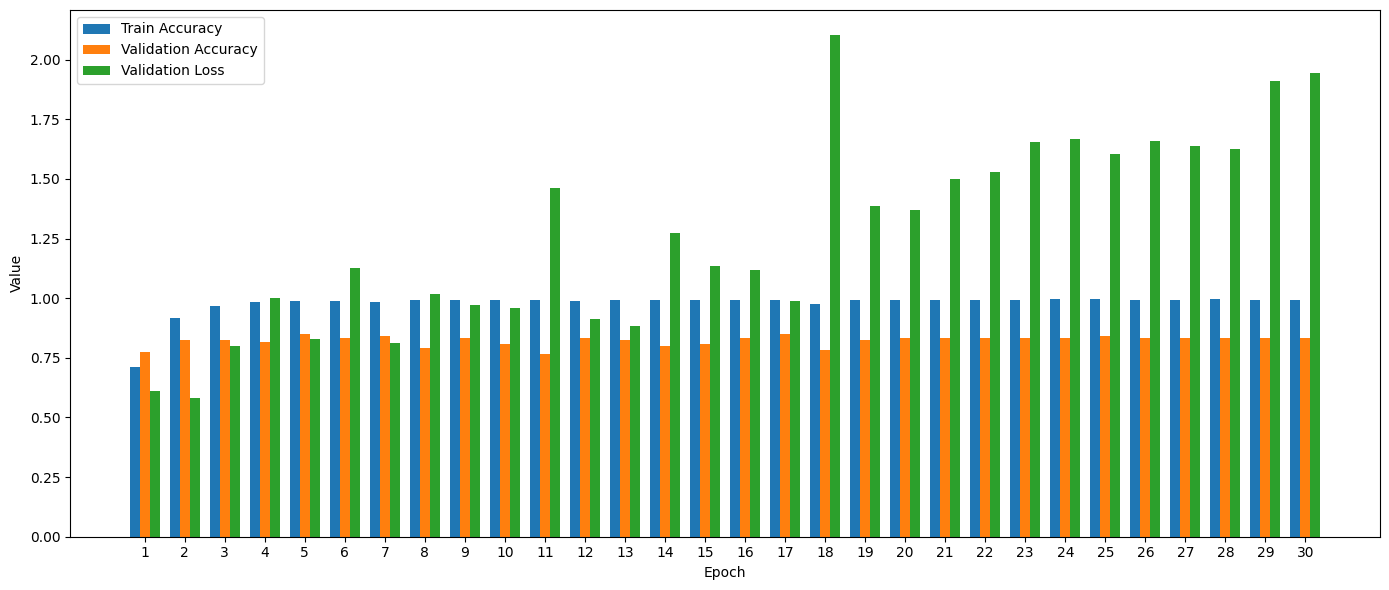

In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np

# LOAD HISTORY
with open("/content/drive/MyDrive/history_afterAug_FT_logits.json", "r") as f:
    history = json.load(f)

train_acc = history["accuracy"]
val_acc   = history["val_accuracy"]
val_loss  = history["val_loss"]

epochs = np.arange(1, len(train_acc) + 1)

width = 0.25  # lebar batang

plt.figure(figsize=(14,6))

plt.bar(epochs - width, train_acc, width=width, label="Train Accuracy")
plt.bar(epochs, val_acc, width=width, label="Validation Accuracy")
plt.bar(epochs + width, val_loss, width=width, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Value")
plt.legend()
plt.xticks(epochs)

plt.tight_layout()
plt.show()

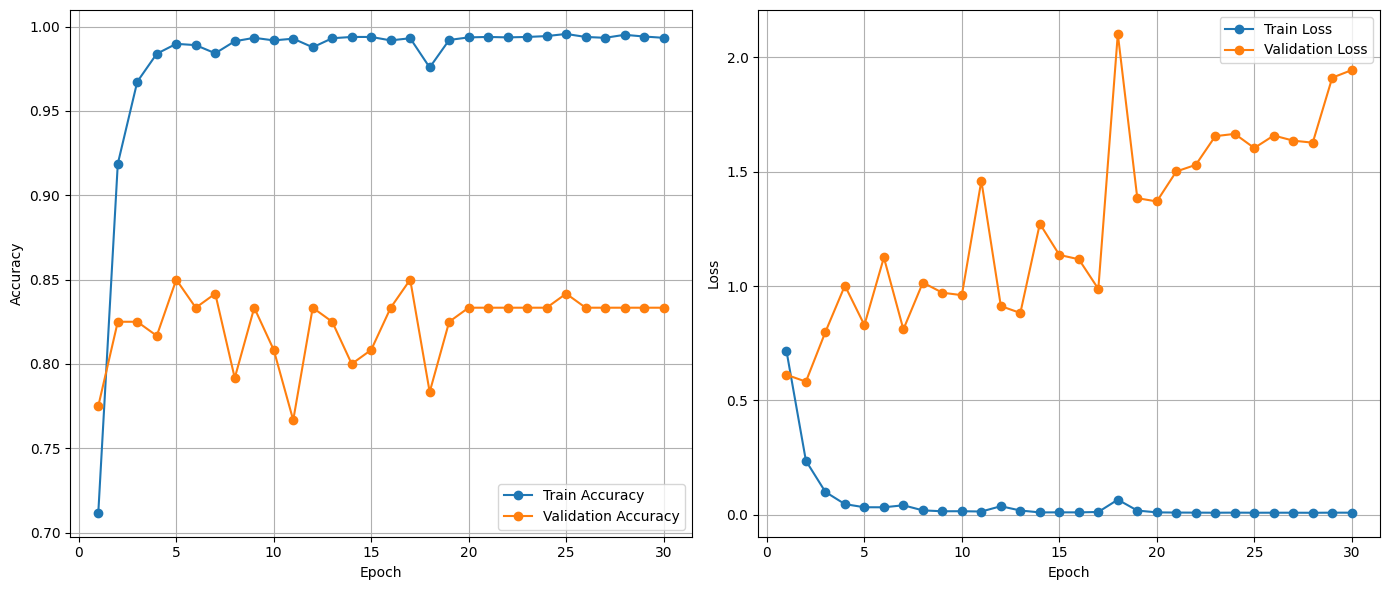

In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np

# 1. LOAD HISTORY
with open("/content/drive/MyDrive/history_afterAug_FT_logits.json", "r") as f:
    history = json.load(f)

# 2. AMBIL DATA
train_acc  = history["accuracy"]
val_acc    = history["val_accuracy"]
train_loss = history["loss"]
val_loss   = history["val_loss"]

# 3. EPOCH
epochs = np.arange(1, len(train_acc) + 1)

# 4. PLOT
plt.figure(figsize=(14,6))

# Accuracy
plt.subplot(1,2,1)
plt.plot(epochs, train_acc, marker='o', label="Train Accuracy")
plt.plot(epochs, val_acc, marker='o', label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1,2,2)
plt.plot(epochs, train_loss, marker='o', label="Train Loss")
plt.plot(epochs, val_loss, marker='o', label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Evaluasi model

Found 120 images belonging to 4 classes.
Classes: ['Geniotrigona thoracica', 'Tetragonula laeviceps', 'Tetragonula testaceitarsis', 'Tetrigona binghami']

Skenario 1 : VGG16 Default (Sebelum Augmentasi & Non FT)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 522ms/step

Classification Report:
                            precision    recall  f1-score   support

    Geniotrigona thoracica     0.6486    0.8000    0.7164        30
     Tetragonula laeviceps     0.8182    0.9000    0.8571        30
Tetragonula testaceitarsis     0.8077    0.7000    0.7500        30
        Tetrigona binghami     0.7083    0.5667    0.6296        30

                  accuracy                         0.7417       120
                 macro avg     0.7457    0.7417    0.7383       120
              weighted avg     0.7457    0.7417    0.7383       120



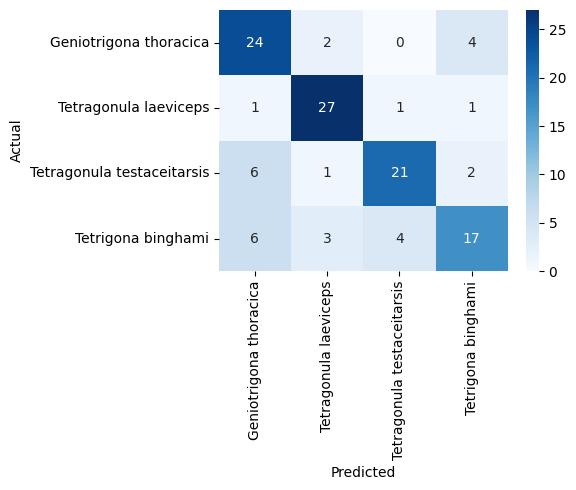


Skenario 2 : Fine-Tuning


4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 590ms/step

Classification Report:
                            precision    recall  f1-score   support

    Geniotrigona thoracica     0.9583    0.7667    0.8519        30
     Tetragonula laeviceps     0.8387    0.8667    0.8525        30
Tetragonula testaceitarsis     0.9310    0.9000    0.9153        30
        Tetrigona binghami     0.7778    0.9333    0.8485        30

                  accuracy                         0.8667       120
                 macro avg     0.8765    0.8667    0.8670       120
              weighted avg     0.8765    0.8667    0.8670       120



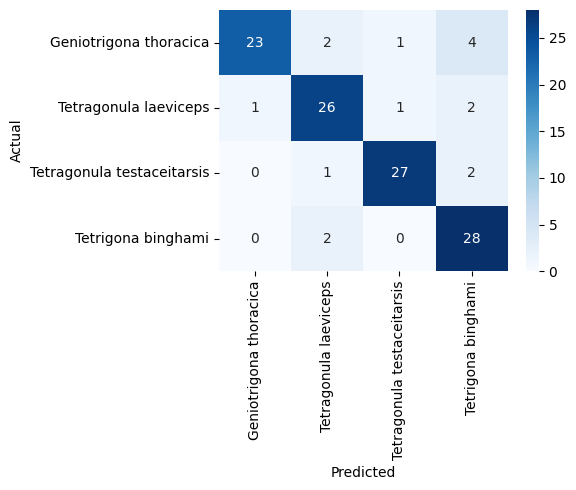


Skenario 3 : Fine-Tuning + Augmentasi


4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 480ms/step

Classification Report:
                            precision    recall  f1-score   support

    Geniotrigona thoracica     0.7500    1.0000    0.8571        30
     Tetragonula laeviceps     0.8889    0.8000    0.8421        30
Tetragonula testaceitarsis     0.9630    0.8667    0.9123        30
        Tetrigona binghami     0.9231    0.8000    0.8571        30

                  accuracy                         0.8667       120
                 macro avg     0.8812    0.8667    0.8672       120
              weighted avg     0.8812    0.8667    0.8672       120



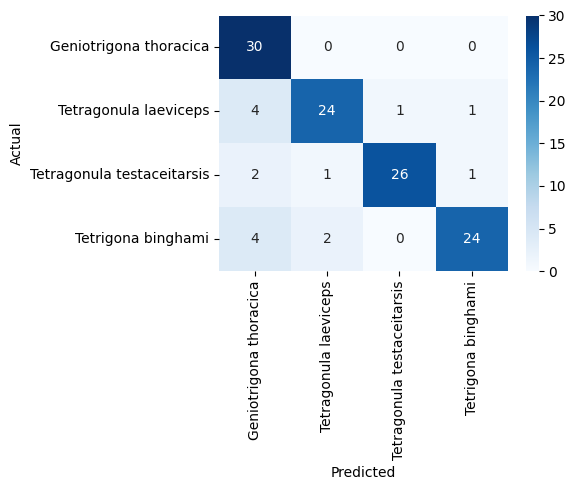

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix

# 1. LOAD TEST DATA
TEST_DIR = "/content/drive/MyDrive/Dataset_Split/test"
IMG_SIZE = (224,224)
BATCH = 32

test_gen = ImageDataGenerator(
    rescale=1./255
).flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode="categorical",
    shuffle=False
)

class_names = list(test_gen.class_indices.keys())
print("Classes:", class_names)

# 2. FUNGSI EVALUASI MODEL
def evaluate_model(model_path, title):
    print("\n" + "="*60)
    print(title)
    print("="*60)

    model = load_model(model_path)

    # PREDIKSI
    preds = model.predict(test_gen)
    y_pred = np.argmax(preds, axis=1)
    y_true = test_gen.classes

    # CLASSIFICATION REPORT
    print("\nClassification Report:")
    print(classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    ))

    # CONFUSION MATRIX
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

# VGG16 default
evaluate_model(
    "/content/drive/MyDrive/model_baseline_logits.h5",
    "Skenario 1 : VGG16 Default (Sebelum Augmentasi & Non FT)"
)

# Fine-Tuning tanpa Augmentasi
evaluate_model(
    "/content/drive/MyDrive/model_finetune_logits.h5",
    "Skenario 2 : Fine-Tuning"
)

# Fine-Tuning + Augmentasi
evaluate_model(
    "/content/drive/MyDrive/model_afterAug_FT_logits.h5",
    "Skenario 3 : Fine-Tuning + Augmentasi"
)


Grafik batang perbandingan classification report

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

TEST_DIR = "/content/drive/MyDrive/Dataset_Split/test"
IMG_SIZE = (224, 224)
BATCH = 32

test_gen = ImageDataGenerator(
    rescale=1./255
).flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode="categorical",
    shuffle=False
)

class_names = list(test_gen.class_indices.keys())
print(class_names)


Found 120 images belonging to 4 classes.
['Geniotrigona thoracica', 'Tetragonula laeviceps', 'Tetragonula testaceitarsis', 'Tetrigona binghami']


In [ ]:
import numpy as np
from sklearn.metrics import classification_report
from tensorflow.keras.models import load_model

def get_cr_scores(model_path):
    model = load_model(model_path)

    preds = model.predict(test_gen, verbose=0)
    y_pred = np.argmax(preds, axis=1)
    y_true = test_gen.classes

    report = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        output_dict=True
    )

    return {
    "accuracy": report["accuracy"],
    "precision": report["macro avg"]["precision"],
    "recall": report["macro avg"]["recall"],
    "f1": report["macro avg"]["f1-score"],
    "macro": report["macro avg"]["f1-score"],
    "weighted": report["weighted avg"]["f1-score"]
}

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from tensorflow.keras.models import load_model

def get_cr_scores(model_path, test_gen, class_names):
    model = load_model(model_path)

    preds = model.predict(test_gen, verbose=0)
    y_pred = np.argmax(preds, axis=1)
    y_true = test_gen.classes

    report = classification_report(
        y_true, y_pred,
        target_names=class_names,
        output_dict=True
    )

   return {
    "accuracy": report["accuracy"],
    "precision": report["macro avg"]["precision"],
    "recall": report["macro avg"]["recall"],
    "f1": report["macro avg"]["f1-score"],
    "macro": report["macro avg"]["f1-score"],
    "weighted": report["weighted avg"]["f1-score"]
}


In [ ]:
s1 = get_cr_scores(
    "/content/drive/MyDrive/model_baseline_logits.h5",
    test_gen,
    class_names
)

s2 = get_cr_scores(
    "/content/drive/MyDrive/model_finetune_logits.h5",
    test_gen,
    class_names
)

s3 = get_cr_scores(
    "/content/drive/MyDrive/model_afterAug_FT_logits.h5",
    test_gen,
    class_names
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


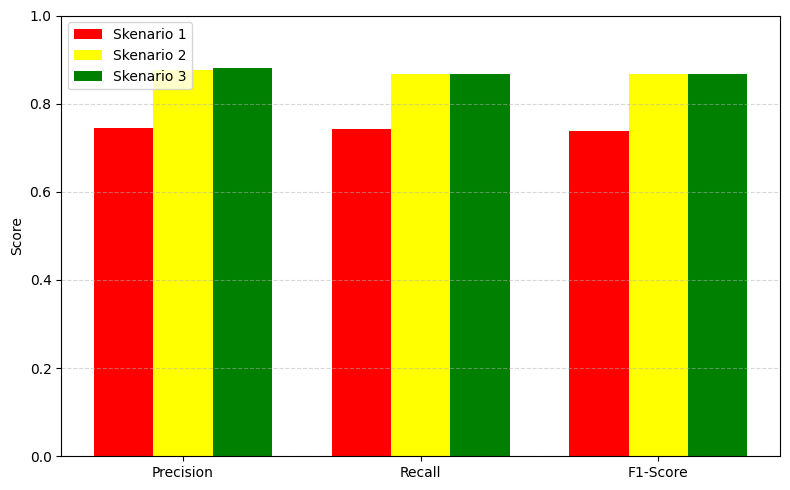

In [ ]:
labels = ["Accuracy", "Precision", "Recall", "F1-Score"]
x = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(8,5))

plt.bar(x - width, [s1["accuracy"], s1["precision"], s1["recall"], s1["f1"]],
        width, label="Skenario 1", color="red")

plt.bar(x, [s2["accuracy"], s2["precision"], s2["recall"], s2["f1"]],
        width, label="Skenario 2", color="yellow")

plt.bar(x + width, [s3["accuracy"], s3["precision"], s3["recall"], s3["f1"]],
        width, label="Skenario 3", color="green")

plt.xticks(x, labels)
plt.ylim(0,1)
plt.ylabel("Score")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


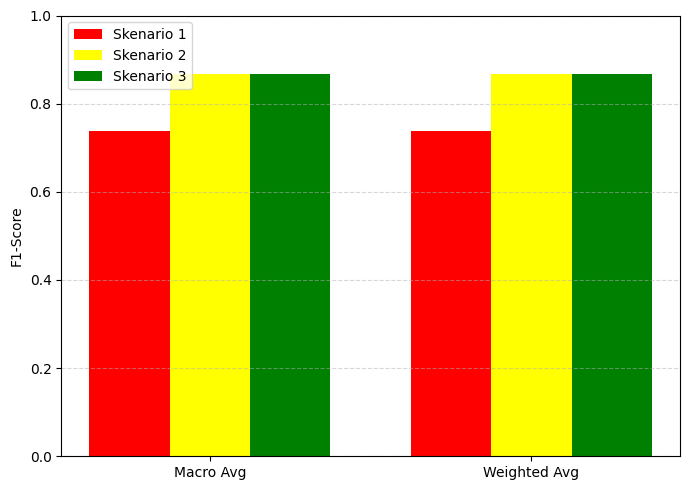

In [ ]:
labels = ["Macro Avg", "Weighted Avg"]
x = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(7,5))

plt.bar(x - width, [s1["macro"], s1["weighted"]],
        width, label="Skenario 1", color="red")
plt.bar(x, [s2["macro"], s2["weighted"]],
        width, label="Skenario 2", color="yellow")
plt.bar(x + width, [s3["macro"], s3["weighted"]],
        width, label="Skenario 3", color="green")

plt.xticks(x, labels)
plt.ylim(0,1)
plt.ylabel("F1-Score")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


perhitungan nilai energy base

In [ ]:
#compute energy lebah

import tensorflow as tf
import numpy as np
import os
from PIL import Image

MODEL_PATH = "/content/drive/MyDrive/model_afterAug_FT_logits.h5"
DATASET = "/content/drive/MyDrive/Dataset_Split/val"

model = tf.keras.models.load_model(MODEL_PATH)

def get_energy(img):
    img = img.resize((224,224))
    x = np.array(img)/255.0
    x = np.expand_dims(x,0)

    logits = model.predict(x, verbose=0)[0]

    energy = -np.log(np.sum(np.exp(logits)))
    return energy

energies = []

for root,_,files in os.walk(DATASET):
    for f in files:
        if f.endswith(("jpg","png","jpeg")):
            path = os.path.join(root,f)
            img = Image.open(path).convert("RGB")
            energies.append(get_energy(img))

print("lebah Energy MIN :", np.min(energies))
print("lebah Energy MAX :", np.max(energies))
print("lebah Energy MEAN:", np.mean(energies))

lebah Energy MIN : -46.451412
lebah Energy MAX : -4.6099887
lebah Energy MEAN: -19.823132


In [ ]:
# compute energy objek

import tensorflow as tf
import numpy as np
import os
from PIL import Image

MODEL_PATH = "/content/drive/MyDrive/model_afterAug_FT_logits.h5"
objek_DIR = "/content/drive/MyDrive/objek"

model = tf.keras.models.load_model(MODEL_PATH)

def get_energy(img):
    img = img.resize((224,224))
    x = np.array(img)/255.0
    x = np.expand_dims(x,0)

    logits = model.predict(x, verbose=0)[0]
    energy = -np.log(np.sum(np.exp(logits)))
    return energy

energies = []

for f in os.listdir(objek_DIR):
    if f.endswith(("jpg","png","jpeg")):
        path = os.path.join(objek_DIR,f)
        img = Image.open(path).convert("RGB")
        energies.append(get_energy(img))

print("objek Energy MIN :", np.min(energies))
print("objek Energy MAX :", np.max(energies))
print("objek Energy MEAN:", np.mean(energies))

objek Energy MIN : -33.538975
objek Energy MAX : -3.594709
objek Energy MEAN: -13.630492


conf

In [ ]:
import tensorflow as tf
import numpy as np
import os
from PIL import Image

MODEL_PATH = "/content/drive/MyDrive/model_afterAug_FT_logits.h5"
DATASET = "/content/drive/MyDrive/Dataset_Split/val"

model = tf.keras.models.load_model(MODEL_PATH)

def get_confidence(img):
    img = img.resize((224,224))
    x = np.array(img)/255.0
    x = np.expand_dims(x,0)

    logits = model.predict(x, verbose=0)[0]

    probs = tf.nn.softmax(logits).numpy()
    confidence = np.max(probs)

    return confidence

confidences = []

for root,_,files in os.walk(DATASET):
    for f in files:
        if f.endswith(("jpg","png","jpeg")):
            path = os.path.join(root,f)
            img = Image.open(path).convert("RGB")
            confidences.append(get_confidence(img))

print("lebah CONF MIN :", np.min(confidences))
print("lebah CONF MAX :", np.max(confidences))
print("lebah CONF MEAN:", np.mean(confidences))

lebah CONF MIN : 0.5127071
lebah CONF MAX : 1.0
lebah CONF MEAN: 0.983796


In [ ]:
import tensorflow as tf
import numpy as np
import os
from PIL import Image

MODEL_PATH = "/content/drive/MyDrive/model_afterAug_FT_logits.h5"
objek_DIR = "/content/drive/MyDrive/user testing/objek"

model = tf.keras.models.load_model(MODEL_PATH)

def get_confidence(img):
    img = img.resize((224,224))
    x = np.array(img)/255.0
    x = np.expand_dims(x,0)

    logits = model.predict(x, verbose=0)[0]

    probs = tf.nn.softmax(logits).numpy()
    confidence = np.max(probs)

    return confidence

confidences = []

for f in os.listdir(objek_DIR):
    if f.endswith(("jpg","png","jpeg")):
        path = os.path.join(objek_DIR,f)
        img = Image.open(path).convert("RGB")
        confidences.append(get_confidence(img))

print("objek CONF MIN :", np.min(confidences))
print("objek CONF MAX :", np.max(confidences))
print("objek CONF MEAN:", np.mean(confidences))

objek CONF MIN : 0.48622397
objek CONF MAX : 1.0
objek CONF MEAN: 0.959064


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

VAL_DIR = "/content/drive/MyDrive/Dataset_Split/val"
IMG_SIZE = (224,224)
BATCH = 32

val_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode="categorical",
    shuffle=False
)

Found 120 images belonging to 4 classes.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
